# Object Classification using Yolo v11n (a lightweight model)

In [1]:
# checking if the notebook is using the virtual environments

import sys

print(sys.executable)


D:\demo\ai_object_detection_demo\.venv\Scripts\python.exe


In [41]:
# importing libraries for image handling and visualization
from PIL import Image # for opening input image
import matplotlib.pyplot as plt # for displaying the input image and for result visualization
import cv2

#using ultralytics libraries to fetch YOLO 11nano version lightweight object detection model
from ultralytics import YOLO


In [3]:
# loading the pretrained model
model = YOLO("yolo11n.pt")


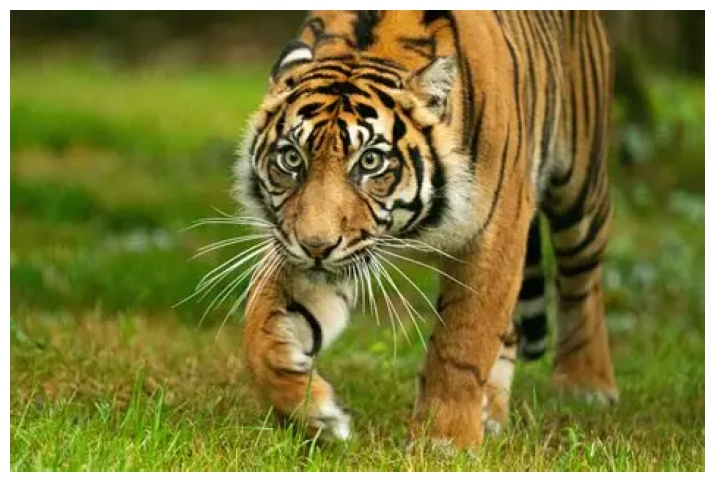

In [4]:
# setting up the image path
image_path = "../images/test.jpg"

# load the image
image = Image.open(image_path)

# display the input image
plt.figure(figsize=(10,6))
plt.imshow(image)
plt.axis("off")
plt.show()


In [17]:
# runing the pretrained model on the test image
results = model(image)



0: 448x640 1 zebra, 138.7ms
Speed: 5.4ms preprocess, 138.7ms inference, 3.1ms postprocess per image at shape (1, 3, 448, 640)


In [18]:
print(type(results))

<class 'list'>


In [19]:
print(results)

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'p

In [27]:
# for first image (test image)
result = results[0]


In [29]:
print(type(result))

<class 'ultralytics.engine.results.Results'>


In [30]:
print(result)

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'po

In [31]:
# Extracting detection information

# getting the predicted class label
class_ids = result.boxes.cls

# getting the bounding box coordinates
# each box coordinate is [x1,y1,x2,y2]
boxes = result.boxes.xyxy

# getting the confidecn score for each detection
confidences = result.boxes.conf


In [32]:
# displaying the predictions
for class_id, box, confidence in zip(class_ids,boxes,confidences):
    # converting the class id from tensor value to integer
    class_id = int(class_id)
    
    # converting the bounding box coordinates to a list
    box = box.tolist()

    # converting the confidence score to regular decimal value
    confidence = float(confidence)

    # getting the class label name
    class_name = result.names[class_id]

    # Display the prediction information.
    print(f"Class ID: {class_id}")
    print(f"Class Name: {class_name}")
    print(f"Bounding Box: {box}")
    print(f"Confidence: {confidence:.2f}")
    print("-" * 40)
    

Class ID: 22
Class Name: zebra
Bounding Box: [147.9502410888672, 1.774828314781189, 416.48980712890625, 301.6578369140625]
Confidence: 0.93
----------------------------------------


In [42]:
# generating annotated image containing
# the detected object, boxes, names and confidence
annotated_image = result.plot(color_mode = "instance")

# overwrite the default color code of the ultralystics
annotated_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)


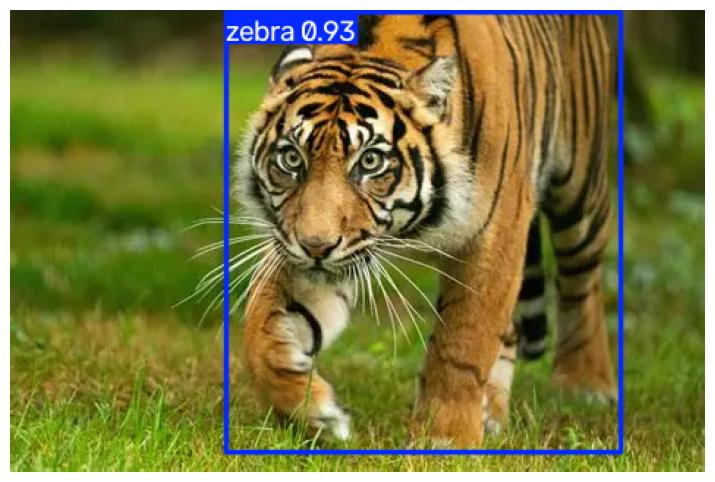

In [43]:
# display the annotated image
plt.figure(figsize=(10,6))
plt.imshow(annotated_image)
plt.axis("off")
plt.show()
